# Text Mining & Social Media Mining — Amazon Reviews (All Beauty dataset)

## Tam Nguyen Bang 475308, Dieu Doan Thi Ngoc 473694


### Covered methods
- **RQ1 (rating-conditioned language):** TF-IDF n-grams, log-odds characteristic terms  
- **RQ2 (themes):** LDA topics (POS vs NEG), clustering (KMeans + silhouette), PCA visualization  
- **RQ3 (engagement/usefulness):** helpfulness modeling (binary + optional count), engineered features, verified stratification  
- **Cross-cutting:** VADER sentiment, POS vs NEG classification, spaCy NER, word correlation network (phi), Word2Vec + PCA

All key tables/figures are produced in a figure-driven way and saved under `OUTPUT_DIR`.


## 0) Setup (Colab-safe installs + reproducibility)

In [1]:

import os, sys, importlib, subprocess, platform, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = "/content/All_Beauty.json"
OUTPUT_DIR = "/content/outputs_allbeauty"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

def ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except Exception:
        pip_install([pip_name or pkg])

# stable set (avoid pinning numpy/scipy)
ensure("tqdm")
ensure("sklearn", "scikit-learn")
ensure("scipy")
ensure("nltk")
ensure("spacy")
ensure("gensim")
ensure("networkx")
ensure("statsmodels")
ensure("wordcloud")

# tensorflow optional (neural baseline)
try:
    import tensorflow as tf
except Exception:
    ensure("tensorflow")

import nltk
for pkg in ["punkt", "stopwords", "vader_lexicon"]:
    try:
        nltk.data.find(pkg)
    except Exception:
        nltk.download(pkg, quiet=True)

import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except Exception:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
    nlp = spacy.load("en_core_web_sm")

print("Ready | Python", platform.python_version(), "| pandas", pd.__version__)
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


Ready | Python 3.12.12 | pandas 2.2.2
DATA_PATH: /content/All_Beauty.json
OUTPUT_DIR: /content/outputs_allbeauty


## 1) Load data (JSON or JSONL)

In [2]:

assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

def read_json_or_jsonl(path):
    try:
        return pd.read_json(path, lines=True)   # jsonl
    except ValueError:
        return pd.read_json(path)              # json

df = read_json_or_jsonl(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(3)


Shape: (371345, 12)
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']


,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,1,True,"02 19, 2015",A1V6B6TNIC10QE,0143026860,theodore j bigham,great,One Star,1424304000,NaN,NaN,NaN
1,4,True,"12 18, 2014",A2F5GHSXFQ0W6J,0143026860,Mary K. Byke,My husband wanted to reading about the Negro ...,... to reading about the Negro Baseball and th...,1418860800,NaN,NaN,NaN
2,4,True,"08 10, 2014",A1572GUYS7DGSR,0143026860,David G,"This book was very informative, covering all a...",Worth the Read,1407628800,NaN,NaN,NaN


Shape: (371345, 35)
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image', 'rating', 'title', 'text', 'helpful_vote', 'verified_purchase', 'timestamp', 'full_text', 'full_text_raw', 'text_norm', 'tokens', 'text_clean', 'rating_bucket', 'vader_score', 'word_len', 'helpful_any', 'log_helpful', 'char_len', 'avg_word_len', 'has_number', 'has_vs', 'has_comparison', 'has_time_marker', 'has_ingredient_term']

Key columns present: ['rating', 'rating_bucket', 'verified_purchase', 'helpful_vote', 'word_len']


,missing_%
image,97.74
vote,86.02
style,66.08
reviewText,0.11
summary,0.06
reviewerName,0.01
overall,0.00
reviewTime,0.00
verified,0.00
reviewerID,0.00


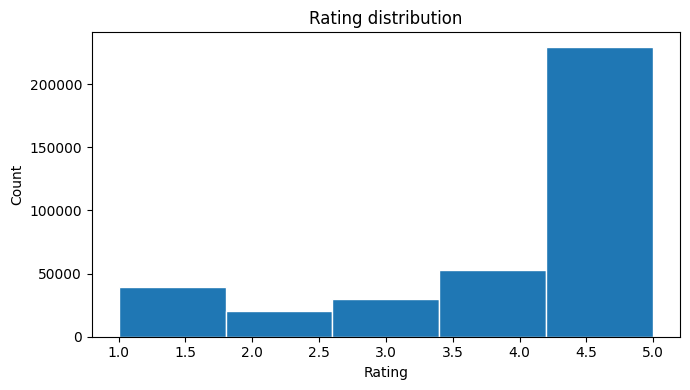

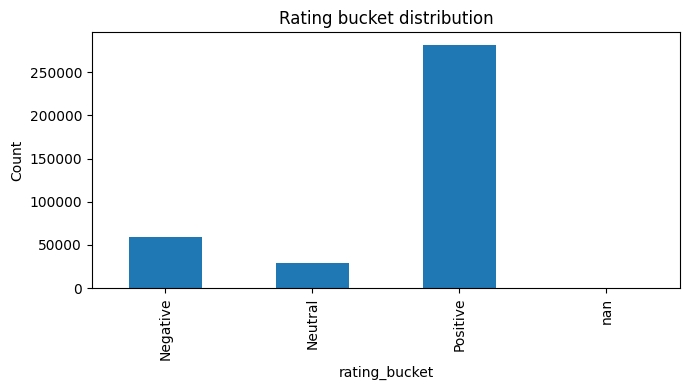

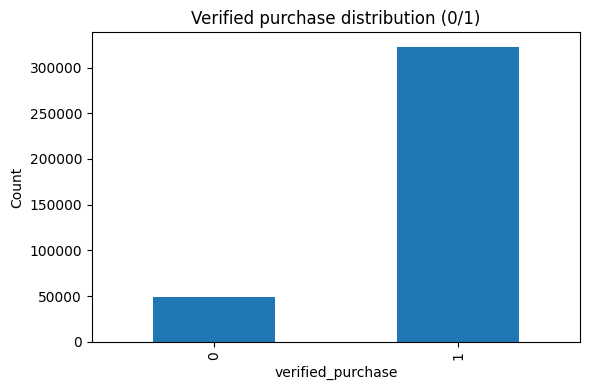

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure word_len exists (for EDA)
if "word_len" not in df.columns:
    df["word_len"] = df["text_clean"].astype(str).str.split().map(len)

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Key columns quick check
key_cols = ["rating","rating_bucket","verified_purchase","helpful_vote","word_len"]
present = [c for c in key_cols if c in df.columns]
print("\nKey columns present:", present)

# Missingness (top)
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing.head(15).to_frame("missing_%"))

# Rating distribution
plt.figure(figsize=(7,4))
df["rating"].dropna().plot(kind="hist", bins=5, edgecolor="white")
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Rating bucket counts
plt.figure(figsize=(7,4))
df["rating_bucket"].value_counts(dropna=False).reindex(["Negative","Neutral","Positive", np.nan]).plot(kind="bar")
plt.title("Rating bucket distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Verified distribution
if "verified_purchase" in df.columns:
    plt.figure(figsize=(6,4))
    df["verified_purchase"].astype(int).value_counts().sort_index().plot(kind="bar")
    plt.title("Verified purchase distribution (0/1)")
    plt.xlabel("verified_purchase")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


<Figure size 800x400 with 0 Axes>

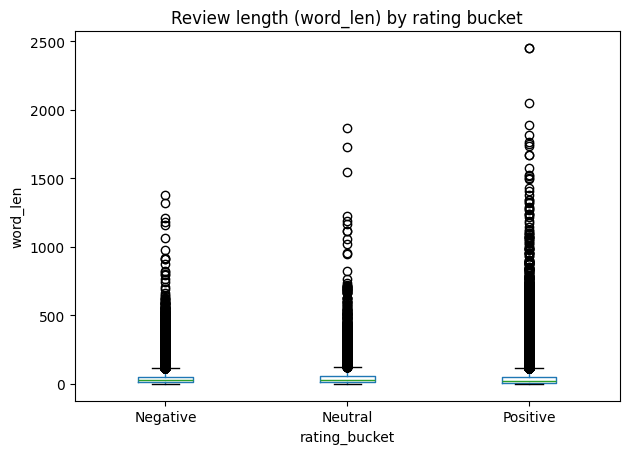

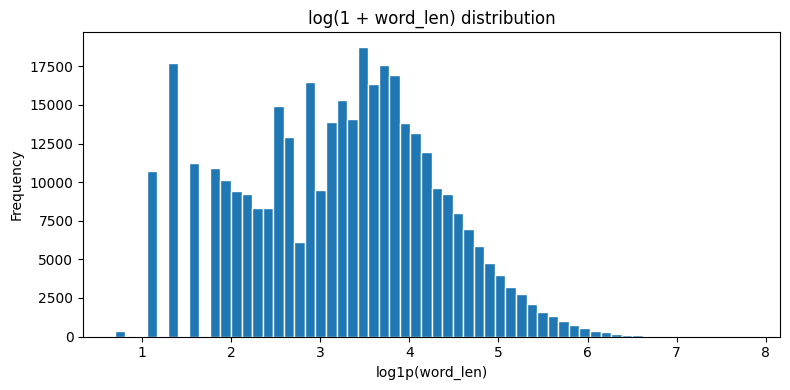

<Figure size 800x400 with 0 Axes>

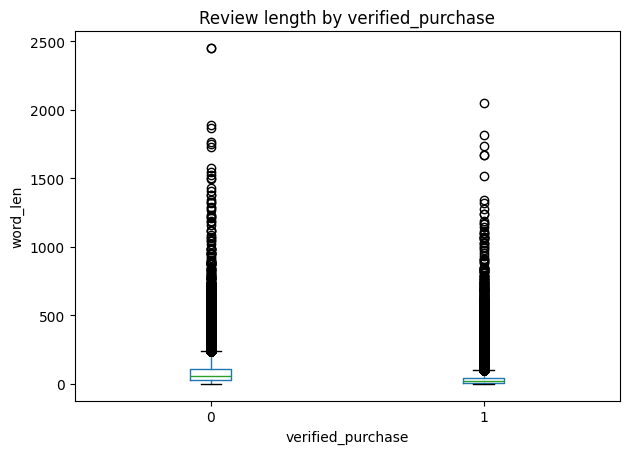

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# word_len by rating_bucket
plt.figure(figsize=(8,4))
tmp = df[df["rating_bucket"].isin(["Negative","Neutral","Positive"])].copy()
tmp.boxplot(column="word_len", by="rating_bucket", grid=False)
plt.title("Review length (word_len) by rating bucket")
plt.suptitle("")
plt.xlabel("rating_bucket")
plt.ylabel("word_len")
plt.tight_layout()
plt.show()

# log length histogram
plt.figure(figsize=(8,4))
np.log1p(df["word_len"]).plot(kind="hist", bins=60, edgecolor="white")
plt.title("log(1 + word_len) distribution")
plt.xlabel("log1p(word_len)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# If verified_purchase exists: length comparison
if "verified_purchase" in df.columns:
    plt.figure(figsize=(8,4))
    tmp2 = df.copy()
    tmp2["verified_purchase"] = tmp2["verified_purchase"].astype(int)
    tmp2.boxplot(column="word_len", by="verified_purchase", grid=False)
    plt.title("Review length by verified_purchase")
    plt.suptitle("")
    plt.xlabel("verified_purchase")
    plt.ylabel("word_len")
    plt.tight_layout()
    plt.show()


,mention_%
skin,9.52
hair,8.73
price,7.46
quality,4.90
smell,4.75
dry,4.09
scent,3.29
razor,2.95
bottle,2.27
shaver,1.76


<Figure size 1000x500 with 0 Axes>

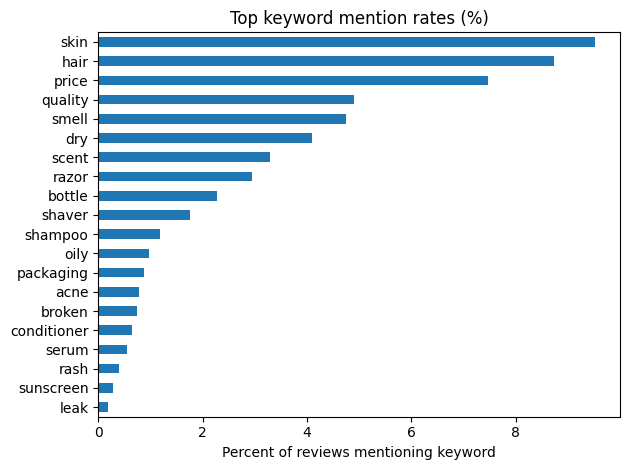

In [31]:
import re
import matplotlib.pyplot as plt

keywords = [
    "skin","hair","smell","scent","dry","oily","acne","rash",
    "bottle","leak","broken","packaging","price","quality",
    "shampoo","conditioner","serum","sunscreen","spf","razor","shaver"
]

text_series = df["full_text"].astype(str).str.lower()

hits = {}
for k in keywords:
    hits[k] = text_series.str.contains(rf"\b{re.escape(k)}\b", regex=True).mean()

kw_df = (pd.Series(hits).sort_values(ascending=False) * 100).round(2).to_frame("mention_%")
display(kw_df.head(20))

plt.figure(figsize=(10,5))
kw_df.head(20).iloc[::-1].plot(kind="barh", legend=False)
plt.title("Top keyword mention rates (%)")
plt.xlabel("Percent of reviews mentioning keyword")
plt.tight_layout()
plt.show()


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

EDA_SAMPLE = min(80_000, len(df))
eda_df = df.sample(EDA_SAMPLE, random_state=SEED).copy()
eda_df = eda_df[eda_df["rating_bucket"].isin(["Negative","Positive","Neutral"])]

cv = CountVectorizer(min_df=50, max_df=0.7, stop_words="english")
X = cv.fit_transform(eda_df["text_clean"])
vocab = np.array(cv.get_feature_names_out())

# overall top words
freq = np.asarray(X.sum(axis=0)).ravel()
top = freq.argsort()[::-1][:30]
top_words = pd.DataFrame({"word": vocab[top], "count": freq[top]})
display(top_words)

# top words per bucket
out = []
for b in ["Negative","Neutral","Positive"]:
    Xi = X[eda_df["rating_bucket"].values == b]
    fi = np.asarray(Xi.sum(axis=0)).ravel()
    ti = fi.argsort()[::-1][:20]
    out.append(pd.DataFrame({"bucket": b, "word": vocab[ti], "count": fi[ti]}))

top_by_bucket = pd.concat(out, ignore_index=True)
display(top_by_bucket.head(30))


,word,count
0,product,26919
1,great,26519
2,love,18876
3,like,17497
4,good,17404
5,use,17192
6,hair,14430
7,skin,12688
8,works,10467
9,really,10343


,bucket,word,count
0,Negative,product,4150
1,Negative,like,3211
2,Negative,hair,2327
3,Negative,use,2026
4,Negative,work,1923
5,Negative,good,1712
6,Negative,money,1570
7,Negative,used,1469
8,Negative,buy,1366
9,Negative,time,1297


## 2) Schema harmonization (prevents KeyError across Amazon dumps)

In [3]:

import numpy as np

def to_int_votes(x):
    if pd.isna(x): return 0
    s = str(x).strip().replace(",", "")
    if s == "": return 0
    try: return int(s)
    except: return 0

# Legacy schema → unified schema
if "overall" in df.columns and "reviewText" in df.columns and "rating" not in df.columns:
    df["rating"] = pd.to_numeric(df["overall"], errors="coerce")
    df["title"]  = df.get("summary", "").fillna("").astype(str)
    df["text"]   = df["reviewText"].fillna("").astype(str)
    df["helpful_vote"] = df["vote"].apply(to_int_votes) if "vote" in df.columns else 0
    df["verified_purchase"] = df["verified"].fillna(False).astype(bool) if "verified" in df.columns else False
    df["timestamp"] = pd.to_numeric(df.get("unixReviewTime", np.nan), errors="coerce") * 1000

# New schema normalizations
if "helpful_votes" in df.columns and "helpful_vote" not in df.columns:
    df["helpful_vote"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)
if "verified_purchase" not in df.columns and "verified" in df.columns:
    df["verified_purchase"] = df["verified"].fillna(False).astype(bool)
if "rating" not in df.columns and "overall" in df.columns:
    df["rating"] = pd.to_numeric(df["overall"], errors="coerce")
if "title" not in df.columns and "summary" in df.columns:
    df["title"] = df["summary"].fillna("").astype(str)
if "text" not in df.columns and "reviewText" in df.columns:
    df["text"] = df["reviewText"].fillna("").astype(str)

# Final unified fields
df["title"] = df.get("title", "").fillna("").astype(str)
df["text"]  = df.get("text", "").fillna("").astype(str)
df["full_text"] = (df["title"].str.strip() + ". " + df["text"].str.strip()).str.strip()

df["helpful_vote"] = pd.to_numeric(df.get("helpful_vote", 0), errors="coerce").fillna(0).astype(int)
df["verified_purchase"] = df.get("verified_purchase", False).fillna(False).astype(bool)
df["rating"] = pd.to_numeric(df.get("rating", np.nan), errors="coerce")

df[["rating","verified_purchase","helpful_vote","full_text"]].head(3)


,rating,verified_purchase,helpful_vote,full_text
0,1,True,0,One Star. great
1,4,True,0,... to reading about the Negro Baseball and th...
2,4,True,0,Worth the Read. This book was very informative...


In [4]:
import re

# Remove boilerplate rating phrases & generic junk before tokenization/vectorization
STAR_PHRASES = [
    r"\b(one|two|three|four|five)\s+stars?\b",
    r"\b\d\s+stars?\b",
    r"\bstar\s+rating\b",
    r"\bfive\s+star\b",
    r"\bone\s+star\b",
    r"\bfour\s+star\b",
    r"\bthree\s+star\b",
    r"\btwo\s+star\b",
]

# Optional: remove Amazon-ish template phrases (keep conservative)
TEMPLATE_PHRASES = [
    r"\bi\s+received\s+this\s+product\s+for\s+free\b",
    r"\bin\s+exchange\s+for\s+my\s+honest\s+review\b",
    r"\bi\s+was\s+given\s+this\s+product\b",
]

STAR_RE = re.compile("|".join(STAR_PHRASES), flags=re.IGNORECASE)
TPL_RE  = re.compile("|".join(TEMPLATE_PHRASES), flags=re.IGNORECASE)

def strip_boilerplate(text: str) -> str:
    s = str(text)
    s = STAR_RE.sub(" ", s)
    s = TPL_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Apply to full_text so downstream steps use the cleaned version
df["full_text_raw"] = df["full_text"]  # keep original for reference
df["full_text"] = df["full_text"].map(strip_boilerplate)

df[["full_text_raw","full_text"]].head(2)


,full_text_raw,full_text
0,One Star. great,. great
1,... to reading about the Negro Baseball and th...,... to reading about the Negro Baseball and th...


## 3) Text preprocessing + tokens + rating buckets

In [5]:
import re
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

STOP = set(stopwords.words("english"))

URL_RE = re.compile(r"https?://\S+|www\.\S+")
NONALPHA_RE = re.compile(r"[^a-zA-Z0-9\s\-]")

tokenizer = RegexpTokenizer(r"[A-Za-z0-9]+")  # fast tokenization

def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = URL_RE.sub(" ", s)
    s = NONALPHA_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def fast_tokens(text: str):
    toks = tokenizer.tokenize(text)
    # remove stopwords + short tokens
    toks = [t for t in toks if len(t) >= 2 and t not in STOP]
    return toks

# vectorized-ish apply (fast enough)
df["text_norm"] = df["full_text"].map(normalize_text)
df["tokens"] = df["text_norm"].map(fast_tokens)
df["text_clean"] = df["tokens"].map(" ".join)

def bucket_rating(r):
    if pd.isna(r): return np.nan
    if r <= 2: return "Negative"
    if r == 3: return "Neutral"
    return "Positive"

df["rating_bucket"] = df["rating"].map(bucket_rating)

print(df["rating_bucket"].value_counts(dropna=False))
df[["rating","rating_bucket","helpful_vote","verified_purchase","text_clean"]].head(3)


rating_bucket
Positive    282236
Negative     59554
Neutral      29555
Name: count, dtype: int64


,rating,rating_bucket,helpful_vote,verified_purchase,text_clean
0,1,Negative,0,True,great
1,4,Positive,0,True,reading negro baseball great addition library ...
2,4,Positive,0,True,worth read book informative covering aspects game


## 4) Cross-cutting — VADER sentiment (polarity + intensity)

VADER agreement with rating_bucket: 0.7697

Confusion matrix:
[[  8659   4315  11114]
 [  1436   1463   9008]
 [  2835   5832 105338]]

Report:
              precision    recall  f1-score   support

    negative       0.67      0.36      0.47     24088
     neutral       0.13      0.12      0.12     11907
    positive       0.84      0.92      0.88    114005

    accuracy                           0.77    150000
   macro avg       0.55      0.47      0.49    150000
weighted avg       0.76      0.77      0.75    150000



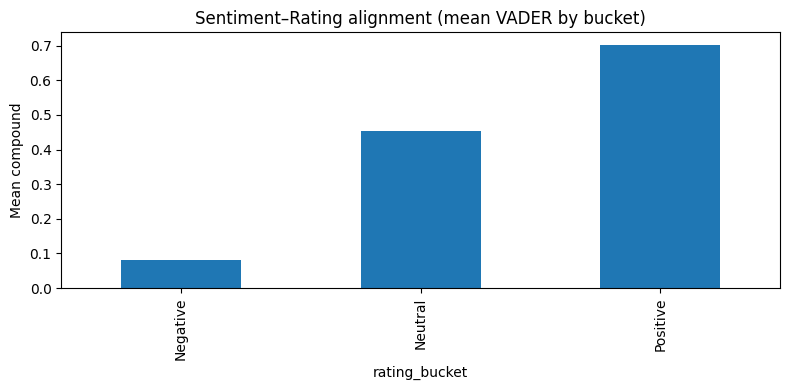

,rating,rating_bucket,vader_score,vader_pred,full_text
253279,3,Neutral,0.8316,positive,Great smell when I first apply the oil. Great ...
33406,3,Neutral,-0.1531,negative,Its a Jack Hammer. My previous Waterpik's hose...
28406,2,Negative,0.8074,positive,Only OK. Ordered this shaver after my old unit...
312195,3,Neutral,0.4767,positive,Too heavy for the ears. The earrings was so be...
234531,3,Neutral,0.7579,positive,I like the fact it's light weight. I like the ...
361606,2,Negative,0.8014,positive,The solid brush works better than the one with...
277666,5,Positive,0.0000,neutral,". If you own a Glock, you should own one of these"
267615,4,Positive,-0.1779,negative,My mother in law has lost the use of her .... ...
320470,3,Neutral,0.9349,positive,A week not good. But love the design. They cha...
79197,2,Negative,0.9274,positive,I was thinking that this would be great to spr...


In [6]:

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, confusion_matrix

sia = SentimentIntensityAnalyzer()
df["vader_score"] = df["text_clean"].map(lambda s: sia.polarity_scores(str(s))["compound"])

def vader_label(score):
    if score >= 0.05: return "positive"
    if score > -0.05: return "neutral"
    return "negative"

SENT_SAMPLE = min(150_000, len(df))
sent_df = df.sample(SENT_SAMPLE, random_state=SEED).copy()
sent_df["vader_pred"] = sent_df["vader_score"].apply(vader_label)

map_bucket = {"Positive":"positive","Neutral":"neutral","Negative":"negative"}
sent_df = sent_df[sent_df["rating_bucket"].isin(map_bucket)].copy()
sent_df["rating_as_sent"] = sent_df["rating_bucket"].map(map_bucket)

acc = (sent_df["vader_pred"] == sent_df["rating_as_sent"]).mean()
print("VADER agreement with rating_bucket:", round(float(acc), 4))

print("\nConfusion matrix:")
print(confusion_matrix(sent_df["rating_as_sent"], sent_df["vader_pred"], labels=["negative","neutral","positive"]))

print("\nReport:")
print(classification_report(sent_df["rating_as_sent"], sent_df["vader_pred"]))

plt.figure(figsize=(8,4))
sent_df.groupby("rating_bucket")["vader_score"].mean().reindex(["Negative","Neutral","Positive"]).plot(kind="bar")
plt.title("Sentiment–Rating alignment (mean VADER by bucket)")
plt.ylabel("Mean compound")
plt.tight_layout()
plt.show()

mismatch = sent_df[sent_df["vader_pred"] != sent_df["rating_as_sent"]]
mismatch[["rating","rating_bucket","vader_score","vader_pred","full_text"]].head(10)


## 5) RQ1 — TF-IDF n-grams (discriminative terms)

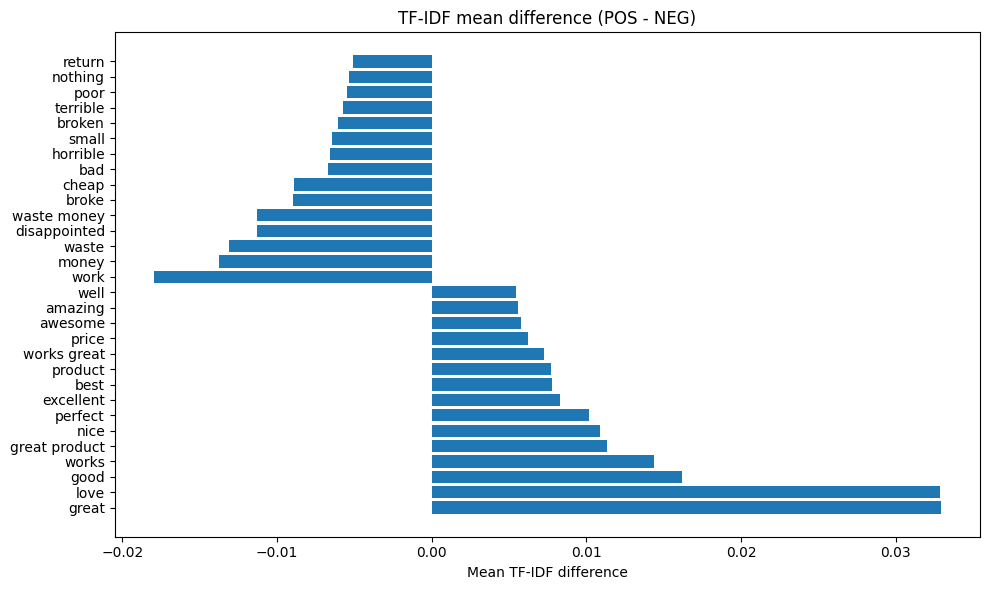

,term,diff_pos_minus_neg,group
0,great,0.032915,POS over
1,love,0.032857,POS over
2,good,0.016216,POS over
3,works,0.014367,POS over
4,great product,0.011304,POS over


In [7]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_bin = df[df["rating_bucket"].isin(["Positive","Negative"])].copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_bin["text_clean"], df_bin["rating_bucket"],
    test_size=0.2, random_state=SEED, stratify=df_bin["rating_bucket"]
)

tfidf = TfidfVectorizer(min_df=10, max_df=0.95, ngram_range=(1,2), sublinear_tf=True)
Xtr = tfidf.fit_transform(X_train)
terms = np.array(tfidf.get_feature_names_out())

mean_pos = Xtr[(y_train=="Positive").values].mean(axis=0)
mean_neg = Xtr[(y_train=="Negative").values].mean(axis=0)
mean_pos = mean_pos.A1 if hasattr(mean_pos,"A1") else np.asarray(mean_pos).ravel()
mean_neg = mean_neg.A1 if hasattr(mean_neg,"A1") else np.asarray(mean_neg).ravel()

diff = mean_pos - mean_neg
top = np.argsort(diff)[::-1][:15]
bot = np.argsort(diff)[:15]

fig_df = pd.DataFrame({
    "term": np.r_[terms[top], terms[bot]],
    "diff_pos_minus_neg": np.r_[diff[top], diff[bot]],
    "group": ["POS over"]*15 + ["NEG over"]*15
})

plt.figure(figsize=(10,6))
plt.barh(fig_df["term"], fig_df["diff_pos_minus_neg"])
plt.title("TF-IDF mean difference (POS - NEG)")
plt.xlabel("Mean TF-IDF difference")
plt.tight_layout()
plt.show()

fig_df.to_csv(os.path.join(OUTPUT_DIR,"rq1_tfidf_term_diff.csv"), index=False)
fig_df.head()


## 6) RQ1 — Log-odds characteristic terms (top 20 each side + examples)

In [8]:

from collections import Counter
import math, re

def log_odds_ratio(tokens_pos, tokens_neg, prior=0.1, topn=20):
    c_pos, c_neg = Counter(tokens_pos), Counter(tokens_neg)
    vocab = set(c_pos) | set(c_neg)
    n_pos, n_neg = sum(c_pos.values()), sum(c_neg.values())

    rows=[]
    for w in vocab:
        a = c_pos[w] + prior
        b = (n_pos - c_pos[w]) + prior
        c = c_neg[w] + prior
        d = (n_neg - c_neg[w]) + prior
        rows.append((w, math.log(a/b) - math.log(c/d), c_pos[w], c_neg[w]))

    rows.sort(key=lambda x: x[1], reverse=True)
    pos_rows = rows[:topn]
    neg_rows = sorted(rows, key=lambda x: x[1])[:topn]

    return (pd.DataFrame(pos_rows, columns=["term","log_odds","count_pos","count_neg"]),
            pd.DataFrame(neg_rows, columns=["term","log_odds","count_pos","count_neg"]))

pos_tokens = [t for toks in df_bin[df_bin["rating_bucket"]=="Positive"]["tokens"] for t in toks]
neg_tokens = [t for toks in df_bin[df_bin["rating_bucket"]=="Negative"]["tokens"] for t in toks]

pos_char, neg_char = log_odds_ratio(pos_tokens, neg_tokens, prior=0.1, topn=20)

def example_snips(term, label, n=2):
    sub = df_bin[df_bin["rating_bucket"]==label]
    hits = sub[sub["text_clean"].str.contains(rf"\b{re.escape(term)}\b", regex=True)]
    return hits["full_text"].head(n).str.slice(0, 140).tolist()

pos_char["examples"] = pos_char["term"].map(lambda w: example_snips(w, "Positive", 2))
neg_char["examples"] = neg_char["term"].map(lambda w: example_snips(w, "Negative", 2))

display(pos_char)
display(neg_char)

pos_char.to_csv(os.path.join(OUTPUT_DIR,"rq1_logodds_pos_terms.csv"), index=False)
neg_char.to_csv(os.path.join(OUTPUT_DIR,"rq1_logodds_neg_terms.csv"), index=False)


,term,log_odds,count_pos,count_neg,examples
0,excelent,6.176429,233,0,"[. Excelent!, Great gift option.. Amazing stan..."
1,borderlands,5.934985,183,0,[BEST DEAL EVER!!!!. I bought both borderlands...
2,powell,5.487970,117,0,[Very good stuff. When you get this stuff you ...
3,relieves,5.379852,105,0,[Added convenience in a busy life. This produc...
4,unbeatable,5.379852,105,0,[So far so good. So far so good. I just bought...
5,calms,5.370292,104,0,[Love it.. There is nothing like relaxing in a...
6,artisanal,5.350892,102,0,[Sweetly Scented Body Cleanser. The Savannah B...
7,valentia,5.331109,100,0,[Wonderful Eye Cream. I get samples/full size ...
8,dlc,5.203410,88,0,[Borderline AMAZING!. Let me start by saying I...
9,antioxidants,5.132874,82,0,"[The Perfect Age Anti-wrinlle Cream is"" A WAR""..."


,term,log_odds,count_pos,count_neg,examples
0,unwearable,-7.216039,0,28,[DRY & DISAPPEARS. Super dry formula. Even tho...
1,aiha,-6.659079,0,16,"[Just a caution. June 4, 2015 Misleading and I..."
2,disapointing,-6.594954,0,15,[still contains Paraben. I cannot believe that...
3,tsar,-6.452870,0,13,[Twice As Much of A Waste As One Bottle!. The ...
4,misrepresentation,-6.373462,0,12,[TERRIBLE. worst misrepresentation I've ever s...
5,booo,-6.287201,0,11,[BOOO!!!. I have used Norelco razors for many ...
6,argin,-6.192791,0,10,[Didn't work for me. Try Colgate Pro-Argin too...
7,puke,-6.088529,0,9,[I threw up. Grossest things alive... The tray...
8,mothballs,-6.088529,0,9,"[DISGUSTING. Harsh smell, reminiscent of potti..."
9,dreadheadhq,-5.972118,0,8,[Wouldn't recommend. Purchase item directly th...


## 7) RQ2 — Topic modeling (LDA) POS vs NEG + representative snippets

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import pandas as pd
import os

# Speed knobs

TOPIC_SAMPLE    = min(80_000, len(df_bin))
MAX_FEATURES    = 60_000
MIN_DF          = 20
N_TOPICS        = 8
TOP_N_WORDS     = 12
SNIP_SAMPLE_POS = 25_000
SNIP_SAMPLE_NEG = 25_000
K_SNIPS         = 2

# Sample
topic_df = df_bin.sample(TOPIC_SAMPLE, random_state=SEED).copy()

# Create POS/NEG masks in topic_df order (IMPORTANT)
pos_mask = (topic_df["rating_bucket"].values == "Positive")
neg_mask = (topic_df["rating_bucket"].values == "Negative")

# Vectorize (fit once)
cv = CountVectorizer(
    max_df=0.95,
    min_df=MIN_DF,
    stop_words="english",
    max_features=MAX_FEATURES
)
X_all = cv.fit_transform(topic_df["text_clean"])
vocab = np.array(cv.get_feature_names_out())

# Slice by boolean mask (correct indexing)
X_pos = X_all[pos_mask]
X_neg = X_all[neg_mask]

# Texts aligned with matrices
pos_texts = topic_df.loc[pos_mask, "full_text"].reset_index(drop=True)
neg_texts = topic_df.loc[neg_mask, "full_text"].reset_index(drop=True)

# LDA (online faster)

lda_pos = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=SEED,
    learning_method="online",
    learning_decay=0.7,
    learning_offset=50.0,
    max_iter=10,
    evaluate_every=-1,
    n_jobs=-1
).fit(X_pos)

lda_neg = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=SEED,
    learning_method="online",
    learning_decay=0.7,
    learning_offset=50.0,
    max_iter=10,
    evaluate_every=-1,
    n_jobs=-1
).fit(X_neg)

def topics_table(model, vocab, top_n=12):
    rows = []
    for i, comp in enumerate(model.components_):
        top = np.argpartition(comp, -top_n)[-top_n:]
        top = top[np.argsort(comp[top])[::-1]]
        rows.append((i, ", ".join(vocab[top])))
    return pd.DataFrame(rows, columns=["topic", "top_words"])

pos_topics = topics_table(lda_pos, vocab, TOP_N_WORDS)
neg_topics = topics_table(lda_neg, vocab, TOP_N_WORDS)

# Representative snippets (transform on subset only)

def representative_snips_fast(lda_model, X, texts, k=2, cap=25000):
    n = X.shape[0]
    if n > cap:
        rng = np.random.default_rng(SEED)
        keep = rng.choice(n, size=cap, replace=False)
        Xs = X[keep]
        ts = texts.iloc[keep].reset_index(drop=True)
    else:
        Xs = X
        ts = texts.reset_index(drop=True)

    dt = lda_model.transform(Xs)
    out = {}
    for t in range(dt.shape[1]):
        idx = np.argsort(dt[:, t])[::-1][:k]
        out[t] = [ts.iloc[i][:140] for i in idx]
    return out

pos_repr = representative_snips_fast(lda_pos, X_pos, pos_texts, k=K_SNIPS, cap=SNIP_SAMPLE_POS)
neg_repr = representative_snips_fast(lda_neg, X_neg, neg_texts, k=K_SNIPS, cap=SNIP_SAMPLE_NEG)

pos_topics["repr_snippets"] = pos_topics["topic"].map(lambda t: pos_repr.get(t, []))
neg_topics["repr_snippets"] = neg_topics["topic"].map(lambda t: neg_repr.get(t, []))

# Perplexity (optional subset for speed)

def perplexity_on_subset(model, X, cap=30000):
    if X.shape[0] > cap:
        idx = np.random.default_rng(SEED).choice(X.shape[0], size=cap, replace=False)
        X = X[idx]
    return float(model.perplexity(X))

print("Perplexity (lower better) POS:", round(perplexity_on_subset(lda_pos, X_pos), 2),
      "| NEG:", round(perplexity_on_subset(lda_neg, X_neg), 2))

display(pos_topics)
display(neg_topics)

pos_topics.to_csv(os.path.join(OUTPUT_DIR, "rq2_lda_pos_topics.csv"), index=False)
neg_topics.to_csv(os.path.join(OUTPUT_DIR, "rq2_lda_neg_topics.csv"), index=False)


Perplexity (lower better) POS: 1225.26 | NEG: 1436.55


,topic,top_words,repr_snippets
0,0,"hair, love, brush, perfect, product, great, us...",[Love this product!!. Best product I have boug...
1,1,"skin, product, use, face, using, works, great,...",[Great cream!. This moisturizer is great! I us...
2,2,"great, good, product, price, razor, works, sha...",[good good good good good good good good good ...
3,3,"best, years, time, used, old, amazon, new, lon...",[I've had one for 35 years. Bought a second .....
4,4,"love, great, smells, nice, smell, scent, aweso...",[I absolutely love this stuff. I absolutely lo...
5,5,"use, water, teeth, easy, like, clean, using, w...",[I use the Ultra Water Flosser twice daily and...
6,6,"worked, review, shower, favorite, fresh, recei...","[Excelente, lo recomiendo. El producto est exc..."
7,7,"love, color, like, amazing, beautiful, really,...",[High quality polish. Really nice quality poli...


,topic,top_words,repr_snippets
0,0,"like, skin, smell, product, face, smells, oil,...",[Strong fragrance. I tried the tester for this...
1,1,"hard, stick, big, lips, shipping, apply, glue,...",[Who put the sticker on the front of a mirror?...
2,2,"product, received, disappointed, item, bottle,...","[No item to review. I cannot review this item,..."
3,3,"money, waste, small, buy, work, cheap, like, f...",[This cape felt like those emergency metalic h...
4,4,"hair, like, quality, brush, picture, expected,...",[bends very easily and looks like cheap really...
5,5,"razor, shave, shaver, water, norelco, years, g...",[.. Terrible razor blades; they do not provide...
6,6,"work, product, using, use, reviews, used, work...",[Zero results.... I have been using this produ...
7,7,"color, broke, look, good, time, price, nice, b...",[Color is different from displayed.. Need to r...


## 8) RQ2 — Clustering (KMeans) TF-IDF + silhouette + PCA scatter

In [12]:

# --- Ensure required columns exist before clustering ---
if "text_clean" not in df.columns:
    raise ValueError("Missing text_clean. Please run preprocessing cell that creates df['text_clean'] first.")

# Create word_len if missing
if "word_len" not in df.columns:
    df["word_len"] = df["text_clean"].astype(str).str.split().map(len)

print("Columns ready:",
      "text_clean" in df.columns,
      "word_len" in df.columns,
      "| example word_len:", df["word_len"].head(3).tolist())


Columns ready: True True | example word_len: [1, 21, 7]


Explained variance (SVD, sum): 0.1265


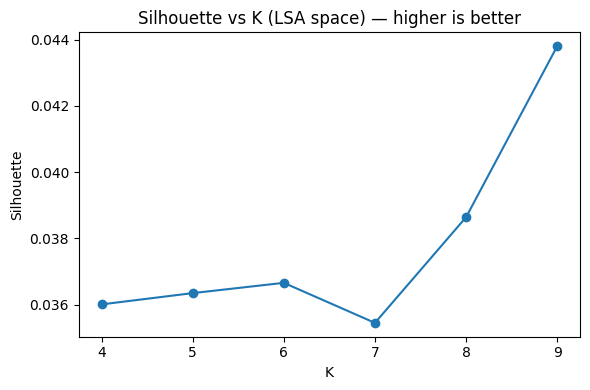

Best K: 9 best silhouette: 0.0438


,cluster,top_terms,n_reviews
0,0,"smell, scent, deodorant, smells, like, natural...",5786
1,1,"soap, bar, scent, soaps, skin, smell, bar soap...",2418
2,2,"skin, product, face, cream, use, using, love, ...",10740
3,3,"link, rvw, arp rvw, ie utf8, class link, data ...",559
4,4,"teeth, waterpik, water, floss, gums, flossing,...",6176
5,5,"hair, product, great, use, shampoo, love, like...",8930
6,6,"lotion, body, body wash, skin, wash, love, sce...",2237
7,7,"product, great, one, like, good, would, use, l...",35896
8,8,"razor, shave, shaver, blades, norelco, shaving...",7258


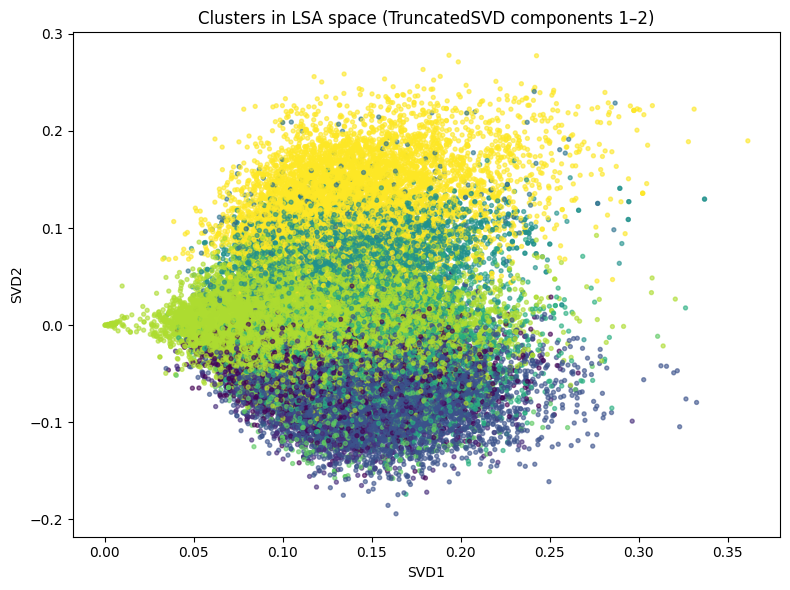

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------
# Speed + quality knobs
# ------------------------
CLUSTER_SAMPLE = min(80_000, len(df))     # 60k–100k OK
MIN_WORDS      = 20                       # filter short reviews => better clusters
MAX_FEATS      = 120_000                  # cap vocab
MIN_DF         = 30                       # reduce noise
SVD_DIM        = 120                      # LSA dimension
Ks             = [4,5,6,7,8,9]            # try a few K

clu_df = df[df["word_len"] >= MIN_WORDS].sample(CLUSTER_SAMPLE, random_state=SEED).copy()

# TF-IDF
vec = TfidfVectorizer(
    min_df=MIN_DF, max_df=0.9,
    ngram_range=(1,2),
    max_features=MAX_FEATS,
    sublinear_tf=True
)
X = vec.fit_transform(clu_df["text_clean"])

# LSA/SVD (works directly on sparse, much better than PCA(toarray))
svd = TruncatedSVD(n_components=SVD_DIM, random_state=SEED)
X_red = svd.fit_transform(X)

print("Explained variance (SVD, sum):", round(float(svd.explained_variance_ratio_.sum()), 4))

# Silhouette selection (on reduced space => faster)
sil = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_red)
    s = silhouette_score(X_red, labels, sample_size=min(15000, len(labels)), random_state=SEED)
    sil.append(s)

plt.figure(figsize=(6,4))
plt.plot(Ks, sil, marker="o")
plt.title("Silhouette vs K (LSA space) — higher is better")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k = Ks[int(np.argmax(sil))]
print("Best K:", best_k, "best silhouette:", round(float(max(sil)), 4))

km = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
clu_df["cluster"] = km.fit_predict(X_red)

# Top terms per cluster (from centroid in TF-IDF space: approximate by mean TF-IDF within cluster)
terms = np.array(vec.get_feature_names_out())
top_terms = []
for c in range(best_k):
    idx = np.where(clu_df["cluster"].values == c)[0]
    Xc = X[idx]
    mean = np.asarray(Xc.mean(axis=0)).ravel()
    top = mean.argsort()[::-1][:12]
    top_terms.append((c, ", ".join(terms[top]), len(idx)))

cluster_terms = pd.DataFrame(top_terms, columns=["cluster","top_terms","n_reviews"]).sort_values("cluster")
display(cluster_terms)

cluster_terms.to_csv(os.path.join(OUTPUT_DIR,"rq2_cluster_top_terms.csv"), index=False)

# 2D visualization using first 2 SVD components (no PCA needed)
plt.figure(figsize=(8,6))
plt.scatter(X_red[:,0], X_red[:,1], s=8, alpha=0.6, c=clu_df["cluster"].values)
plt.title("Clusters in LSA space (TruncatedSVD components 1–2)")
plt.xlabel("SVD1")
plt.ylabel("SVD2")
plt.tight_layout()
plt.show()


## 9) RQ3 — Feature engineering for helpfulness (zero-inflated helpful votes)

In [15]:

import re

df["helpful_any"] = (df["helpful_vote"] > 0).astype(int)
df["log_helpful"] = np.log1p(df["helpful_vote"])

df["char_len"] = df["full_text"].str.len()
df["word_len"] = df["full_text"].str.split().map(lambda x: len(x) if isinstance(x, list) else 0)
df["avg_word_len"] = df["full_text"].str.split().map(lambda ws: np.mean([len(w) for w in ws]) if isinstance(ws, list) and len(ws)>0 else 0)

df["has_number"] = df["full_text"].str.contains(r"\d", regex=True).astype(int)
df["has_vs"] = df["full_text"].str.contains(r"\bvs\b|\bversus\b", case=False, regex=True).astype(int)
df["has_comparison"] = df["full_text"].str.contains(r"\bbetter than\b|\bworse than\b|\bmore than\b|\bless than\b", case=False, regex=True).astype(int)
df["has_time_marker"] = df["full_text"].str.contains(r"\bday\b|\bweek\b|\bweeks\b|\bmonth\b|\bmonths\b|\byear\b|\byears\b|\bafter\b|\bsince\b", case=False, regex=True).astype(int)

ingredient_terms = ["retinol","hyaluronic","niacinamide","vitamin c","salicylic","glycolic","ceramide","collagen","spf","sunscreen","serum","toner"]
pattern = "|".join([re.escape(t) for t in ingredient_terms])
df["has_ingredient_term"] = df["full_text"].str.lower().str.contains(pattern, regex=True).astype(int)

df[["helpful_vote","helpful_any","word_len","avg_word_len","has_number","has_comparison","has_time_marker","has_ingredient_term","verified_purchase","vader_score"]].head(3)


,helpful_vote,helpful_any,word_len,avg_word_len,has_number,has_comparison,has_time_marker,has_ingredient_term,verified_purchase,vader_score
0,0,0,2,3.00,0,0,0,0,True,0.6249
1,0,0,50,4.88,0,0,0,0,True,0.8481
2,0,0,13,5.00,0,0,0,0,True,0.2263


## 10) RQ3 — Predict helpfulness (binary) + AUC/F1/Acc + stratified verified

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Helpfulness(binary) — AUC: 0.7455 | F1: 0.3983 | Acc: 0.7288


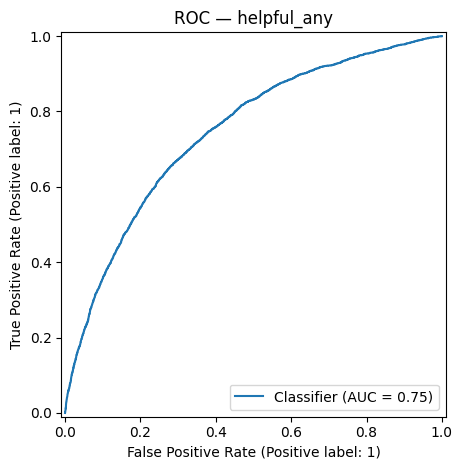

AUC verified=0: 0.6786 (n=3302)
AUC verified=1: 0.7435 (n=20698)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# 0) Type safety (no bools in numeric imputer)
# =========================
bool_cols = [
    "has_number","has_vs","has_comparison","has_time_marker",
    "has_ingredient_term","verified_purchase","helpful_any"
]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype("int8")

num_cols = ["char_len","word_len","avg_word_len","vader_score","helpful_vote"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# 1) Speed knobs (tune if needed)
# =========================
ENG_SAMPLE = min(120_000, len(df))   # 80k–150k recommended on Colab
MIN_DF     = 30                      # reduce rare terms (faster, more stable)
MAX_FEATS  = 120_000                 # cap vocabulary size
MAX_ITER   = 400                     # fewer iters (faster); increase if needed

# =========================
# 2) Data
# =========================
eng_df = df[df["word_len"] > 2].sample(ENG_SAMPLE, random_state=SEED).copy()

X = eng_df[[
    "text_clean","char_len","word_len","avg_word_len",
    "has_number","has_vs","has_comparison","has_time_marker",
    "has_ingredient_term","vader_score","verified_purchase"
]]
y = eng_df["helpful_any"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# =========================
# 3) Pipeline (TF-IDF + numeric + verified)
# =========================
pre = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             min_df=MIN_DF, max_df=0.95,
             ngram_range=(1,2),
             max_features=MAX_FEATS,
             sublinear_tf=True
         ),
         "text_clean"),

        ("num",
         Pipeline([("imp", SimpleImputer(strategy="median"))]),
         ["char_len","word_len","avg_word_len",
          "has_number","has_vs","has_comparison","has_time_marker",
          "has_ingredient_term","vader_score"]),

        ("cat",
         Pipeline([
             ("imp", SimpleImputer(strategy="most_frequent")),
             ("oh", OneHotEncoder(handle_unknown="ignore"))
         ]),
         ["verified_purchase"])
    ],
    sparse_threshold=0.1
)

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        solver="saga",           # fast for large sparse matrices
        max_iter=MAX_ITER,
        n_jobs=-1,
        class_weight="balanced"  # helpful_any usually imbalanced
    ))
])

# =========================
# 4) Train + Evaluate
# =========================
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
f1  = f1_score(y_test, pred)
acc = accuracy_score(y_test, pred)

print("Helpfulness(binary) — AUC:", round(float(auc), 4),
      "| F1:", round(float(f1), 4),
      "| Acc:", round(float(acc), 4))

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("ROC — helpful_any")
plt.tight_layout()
plt.show()

# Stratified AUC: verified vs non-verified
for v in [0, 1]:
    m = (X_test["verified_purchase"].astype(int) == v)
    if m.sum() >= 50 and len(np.unique(y_test[m])) > 1:
        print(f"AUC verified={v}: {roc_auc_score(y_test[m], proba[m]):.4f} (n={m.sum()})")

# Save
pd.DataFrame([{
    "model": "helpful_any_logreg_saga",
    "sample_n": len(eng_df),
    "min_df": MIN_DF,
    "max_features": MAX_FEATS,
    "auc": auc,
    "f1": f1,
    "acc": acc
}]).to_csv(os.path.join(OUTPUT_DIR, "rq3_helpful_binary_performance.csv"), index=False)


## 11) RQ3 — Count modeling (optional): Poisson vs Negative Binomial for helpful_vote

In [17]:

import statsmodels.api as sm
import statsmodels.formula.api as smf

count_df = df[df["word_len"] >= 3].copy()
count_df["verified_int"] = count_df["verified_purchase"].astype(int)

formula = "helpful_vote ~ word_len + avg_word_len + has_number + has_comparison + has_time_marker + has_ingredient_term + vader_score + verified_int"

poisson_model = smf.glm(formula=formula, data=count_df, family=sm.families.Poisson()).fit()
nb_model      = smf.glm(formula=formula, data=count_df, family=sm.families.NegativeBinomial()).fit()

print("Poisson coefficients:")
print(poisson_model.summary().tables[1])

print("\nNegative Binomial coefficients:")
print(nb_model.summary().tables[1])

coef_tbl = pd.DataFrame({
    "feature": nb_model.params.index,
    "coef": nb_model.params.values,
    "pvalue": nb_model.pvalues.values
}).sort_values("pvalue")

coef_tbl.to_csv(os.path.join(OUTPUT_DIR,"rq3_nb_coefficients.csv"), index=False)
coef_tbl.head(12)


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Poisson coefficients:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.9450      0.008   -112.252      0.000      -0.961      -0.928
word_len                0.0026   5.31e-06    488.055      0.000       0.003       0.003
avg_word_len            0.1614      0.002    103.159      0.000       0.158       0.165
has_number              0.7986      0.004    210.936      0.000       0.791       0.806
has_comparison          0.1472      0.006     25.978      0.000       0.136       0.158
has_time_marker         0.6782      0.004    179.425      0.000       0.671       0.686
has_ingredient_term     0.0508      0.008      6.249      0.000       0.035       0.067
vader_score             0.0994      0.004     26.179      0.000       0.092       0.107
verified_int           -0.5953      0.004   -162.706      0.000      -0.602      -0.588

Negative 

,feature,coef,pvalue
0,Intercept,-1.308862,0.000000e+00
1,word_len,0.011488,0.000000e+00
2,avg_word_len,0.179231,0.000000e+00
3,has_number,0.358696,0.000000e+00
5,has_time_marker,0.279776,0.000000e+00
8,verified_int,-0.536986,0.000000e+00
7,vader_score,-0.147639,1.610941e-137
6,has_ingredient_term,0.312250,1.019557e-73
4,has_comparison,-0.082481,2.139952e-11


## 12) Cross-cutting — POS vs NEG supervised classification (LogReg / NB / LinearSVC calibrated)


=== LogReg AUC 0.9708 ===
              precision    recall  f1-score   support

    Negative       0.89      0.75      0.81     11911
    Positive       0.95      0.98      0.96     56447

    accuracy                           0.94     68358
   macro avg       0.92      0.86      0.89     68358
weighted avg       0.94      0.94      0.94     68358

Confusion matrix:
 [[ 8898  3013]
 [ 1082 55365]]


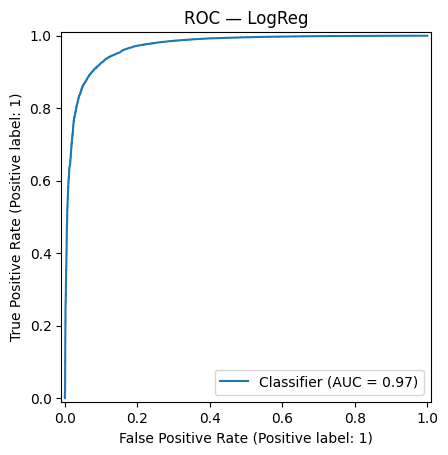


=== NB AUC 0.9659 ===
              precision    recall  f1-score   support

    Negative       0.92      0.61      0.73     11911
    Positive       0.92      0.99      0.95     56447

    accuracy                           0.92     68358
   macro avg       0.92      0.80      0.84     68358
weighted avg       0.92      0.92      0.92     68358

Confusion matrix:
 [[ 7281  4630]
 [  675 55772]]


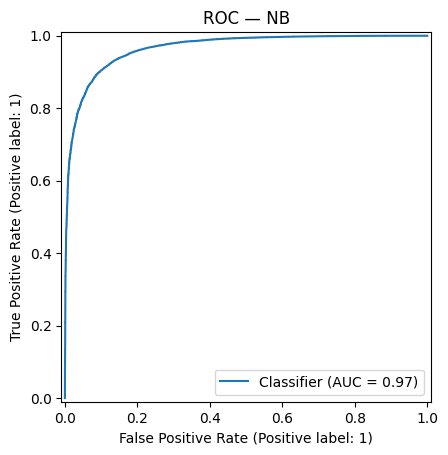


=== LinearSVC(cal) AUC 0.9725 ===
              precision    recall  f1-score   support

    Negative       0.88      0.78      0.82     11911
    Positive       0.95      0.98      0.97     56447

    accuracy                           0.94     68358
   macro avg       0.92      0.88      0.90     68358
weighted avg       0.94      0.94      0.94     68358

Confusion matrix:
 [[ 9267  2644]
 [ 1291 55156]]


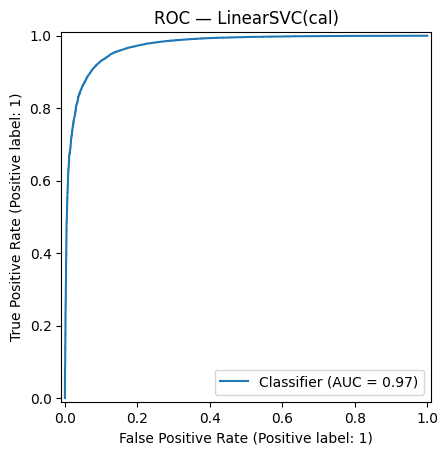

,model,roc_auc
2,LinearSVC(cal),0.972490
0,LogReg,0.970809
1,NB,0.965853


In [18]:

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_bin2 = df[df["rating_bucket"].isin(["Positive","Negative"])].copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_bin2["text_clean"], df_bin2["rating_bucket"],
    test_size=0.2, random_state=SEED, stratify=df_bin2["rating_bucket"]
)

vec = TfidfVectorizer(min_df=10, max_df=0.95, ngram_range=(1,2), sublinear_tf=True)
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)

le = LabelEncoder()
ytr = le.fit_transform(y_train)
yte = le.transform(y_test)

models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "NB": MultinomialNB(alpha=0.5),
    "LinearSVC(cal)": CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3)
}

rows=[]
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    proba = clf.predict_proba(Xte)[:,1]
    auc = roc_auc_score(yte, proba)

    print("\n===", name, "AUC", round(float(auc),4), "===")
    print(classification_report(yte, pred, target_names=le.classes_))
    print("Confusion matrix:\n", confusion_matrix(yte, pred))

    RocCurveDisplay.from_predictions(yte, proba)
    plt.title(f"ROC — {name}")
    plt.show()

    rows.append({"model":name, "roc_auc":auc})

perf = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
perf.to_csv(os.path.join(OUTPUT_DIR,"posneg_classification_performance.csv"), index=False)
perf


## 13) Cross-cutting — spaCy NER (labels + top entities + examples)

In [21]:
import spacy
from spacy.pipeline import EntityRuler
import re

# =========================
# 0) Ensure spaCy model loaded
# =========================
try:
    nlp
except NameError:
    nlp = spacy.load("en_core_web_sm")

# =========================
# 1) Add / replace EntityRuler
# =========================
if "entity_ruler" in nlp.pipe_names:
    nlp.remove_pipe("entity_ruler")

# put before ner so ruler labels are created early
ruler = nlp.add_pipe("entity_ruler", before="ner")

# =========================
# 2) Lexicons (expand as needed)
# =========================
brands = [
    "CeraVe","Neutrogena","Olay","Maybelline","L'Oreal","Revlon","Dove",
    "Aveeno","Nivea","Cetaphil","Garnier","Pantene","Head and Shoulders",
    "Philips Norelco","Norelco","Waterpik","La Roche-Posay","The Ordinary"
]

ingredients = [
    "retinol","hyaluronic acid","niacinamide","vitamin c","salicylic acid",
    "glycolic acid","ceramide","ceramides","collagen","benzoyl peroxide",
    "shea butter","argan oil","tea tree oil","aloe vera","panthenol",
    "azelaic acid","lactic acid","peptides"
]

product_types = [
    "sunscreen","spf","serum","toner","moisturizer","cleanser","face wash",
    "shampoo","conditioner","razor","shaver","soap","lotion","cream",
    "foundation","concealer","lipstick","mascara","eyeliner","nail polish"
]

# =========================
# 3) Build patterns (token patterns + regex)
# =========================
patterns = []

# --- brands: exact phrases, case-insensitive
for b in brands:
    patterns.append({"label": "BRAND", "pattern": b})

# --- ingredients: multi-word token patterns (LOWER)
for ing in ingredients:
    patterns.append({
        "label": "INGREDIENT",
        "pattern": [{"LOWER": w} for w in ing.split()]
    })

# --- product types
for p in product_types:
    # allow "spf" as product-type; keep both token and phrase
    patterns.append({
        "label": "PRODUCT",
        "pattern": [{"LOWER": w} for w in p.split()]
    })

# --- regex patterns (useful for domain signals)
# SPF 30 / SPF50 / SPF 50+
patterns += [
    {"label": "PRODUCT", "pattern": [{"LOWER": {"REGEX": r"spf\d{1,3}\+?"}}]},
    {"label": "PRODUCT", "pattern": [{"LOWER": "spf"}, {"TEXT": {"REGEX": r"^\d{1,3}\+?$"}}]},
]

# Add all patterns
ruler.add_patterns(patterns)

print("EntityRuler added.")
print("Patterns:", len(patterns))
print("Pipeline:", nlp.pipe_names)

# =========================
# 4) Quick sanity check on a few texts
# =========================
test_samples = [
    "I love CeraVe moisturizer with niacinamide. SPF 50 is perfect for my skin.",
    "This Philips Norelco shaver irritated my skin. Tea tree oil helped later.",
    "The Ordinary hyaluronic acid serum works great, but the bottle leaks."
]
for s in test_samples:
    doc = nlp(s)
    dom_ents = [(e.text, e.label_) for e in doc.ents if e.label_ in {"BRAND","INGREDIENT","PRODUCT"}]
    print("\nTEXT:", s)
    print("DOMAIN ENTS:", dom_ents)


✅ EntityRuler added.
Patterns: 58
Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']

TEXT: I love CeraVe moisturizer with niacinamide. SPF 50 is perfect for my skin.
DOMAIN ENTS: [('CeraVe', 'BRAND'), ('moisturizer', 'PRODUCT'), ('niacinamide', 'INGREDIENT'), ('SPF 50', 'PRODUCT')]

TEXT: This Philips Norelco shaver irritated my skin. Tea tree oil helped later.
DOMAIN ENTS: [('Philips Norelco', 'BRAND'), ('shaver', 'PRODUCT'), ('Tea tree oil', 'INGREDIENT')]

TEXT: The Ordinary hyaluronic acid serum works great, but the bottle leaks.
DOMAIN ENTS: [('The Ordinary', 'BRAND'), ('hyaluronic acid', 'INGREDIENT'), ('serum', 'PRODUCT')]


In [24]:
from collections import Counter

NER_SAMPLE = min(8000, len(df))
ner_df = df.sample(NER_SAMPLE, random_state=SEED).copy()

docs = list(nlp.pipe(ner_df["full_text"].tolist(), batch_size=64))

ents = []
labels = []
for doc in docs:
    for ent in doc.ents:
        ents.append(ent.text.strip())
        labels.append(ent.label_)

label_counts = Counter(labels)
ent_counts = Counter(ents)

print("Top entity labels:", label_counts.most_common(12))
print("\nTop entities:", ent_counts.most_common(25))

# Focus domain entities
domain_labels = {"BRAND","INGREDIENT","PRODUCT"}
domain_ents = [e for e,l in zip(ents, labels) if l in domain_labels]
print("\nTop domain entities:", Counter(domain_ents).most_common(25))

# A few examples
for i in range(3):
    print("\n--- Example ---")
    print(ner_df.iloc[i]["full_text"][:260], "...")
    print([(e.text, e.label_) for e in docs[i].ents if e.label_ in domain_labels][:12])


Top entity labels: [('PRODUCT', 2499), ('DATE', 2357), ('CARDINAL', 1847), ('ORG', 1658), ('PERSON', 1190), ('ORDINAL', 660), ('TIME', 513), ('GPE', 325), ('BRAND', 323), ('MONEY', 247), ('NORP', 210), ('WORK_OF_ART', 124)]

Top entities: [('first', 420), ('razor', 375), ('soap', 324), ('shaver', 298), ('one', 284), ('cream', 270), ('2', 170), ('Amazon', 167), ('lotion', 154), ('shampoo', 153), ('two', 147), ('Waterpik', 126), ('Norelco', 126), ('3', 125), ('years', 124), ('second', 104), ('serum', 89), ('three', 86), ('moisturizer', 85), ('daily', 82), ('One', 81), ('1', 80), ('all day', 79), ('4', 75), ('conditioner', 74)]

Top domain entities: [('razor', 375), ('soap', 324), ('shaver', 298), ('cream', 270), ('lotion', 154), ('shampoo', 153), ('Waterpik', 126), ('Norelco', 126), ('serum', 89), ('moisturizer', 85), ('conditioner', 74), ('lipstick', 65), ('foundation', 55), ('cleanser', 42), ('Razor', 41), ('sunscreen', 37), ('mascara', 34), ('Shaver', 33), ('Cream', 32), ('eyeliner', 

## 14) Cross-cutting — Word correlation network (phi coefficient)

,term1,term2,phi,n11
39,recommend,highly,0.457165,343
80,shave,close,0.412581,192
75,razor,shave,0.381590,224
79,shave,shaver,0.376874,179
38,best,ever,0.356161,349
81,shave,shaving,0.351715,155
84,fast,shipping,0.346290,139
77,razor,shaving,0.319324,143
64,water,waterpik,0.313415,155
78,razor,blades,0.298761,127


Graph nodes: 97 edges: 94


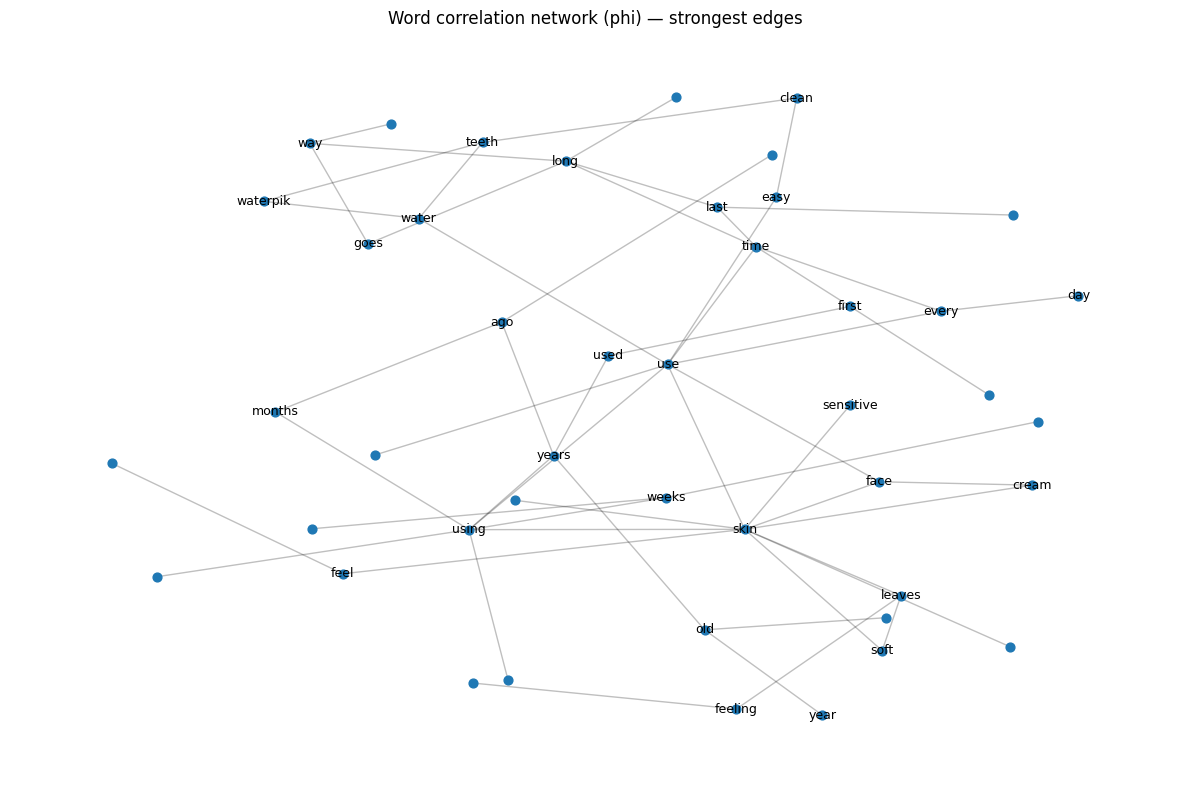

In [25]:

from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import math

NET_SAMPLE = min(20000, len(df))
net_df = df.sample(NET_SAMPLE, random_state=SEED).copy()

cv = CountVectorizer(min_df=20, max_df=0.8, binary=True)
Xb = cv.fit_transform(net_df["text_clean"])
vocab = np.array(cv.get_feature_names_out())

dfreq = np.asarray(Xb.sum(axis=0)).ravel()
top_idx = dfreq.argsort()[::-1][:250]
Xtop = Xb[:, top_idx]
vtop = vocab[top_idx]

N = Xtop.shape[0]
Xtop_bin = (Xtop > 0).astype(int)
co = (Xtop_bin.T @ Xtop_bin).toarray()
n1 = np.diag(co)

pairs=[]
for i in range(len(vtop)):
    for j in range(i+1, len(vtop)):
        n11 = co[i,j]
        if n11 < 25:
            continue
        n10 = n1[i] - n11
        n01 = n1[j] - n11
        n00 = N - n11 - n10 - n01
        denom = math.sqrt((n11+n10)*(n01+n00)*(n11+n01)*(n10+n00))
        if denom == 0:
            continue
        phi = (n11*n00 - n10*n01) / denom
        if phi > 0.15:
            pairs.append((vtop[i], vtop[j], float(phi), int(n11)))

phi_df = pd.DataFrame(pairs, columns=["term1","term2","phi","n11"]).sort_values(["phi","n11"], ascending=False)
display(phi_df.head(15))
phi_df.to_csv(os.path.join(OUTPUT_DIR,"phi_pairs.csv"), index=False)

# Optional quick network plot (top edges)
G = nx.Graph()
for a,b,phi,n11 in pairs[:2000]:
    G.add_edge(a,b, weight=phi, n11=n11)

print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    H = G.subgraph(largest_cc).copy()
    edges_sorted = sorted(H.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:250]
    H2 = nx.Graph()
    for u,v,d in edges_sorted:
        H2.add_edge(u,v, weight=d["weight"])

    plt.figure(figsize=(12,8))
    pos = nx.spring_layout(H2, seed=SEED, k=0.35)
    nx.draw_networkx_nodes(H2, pos, node_size=40)
    nx.draw_networkx_edges(H2, pos, alpha=0.25)
    degrees = dict(H2.degree())
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:30]  # top 30 hubs
    labels = {n: n for n in top_nodes}
    nx.draw_networkx_labels(H2, pos, labels=labels, font_size=9)
    plt.title("Word correlation network (phi) — strongest edges")
    plt.axis("off")
    plt.tight_layout()
    plt.show()



## 15) Cross-cutting — Word2Vec embeddings + PCA visualization

Word2Vec<vocab=12286, vector_size=100, alpha=0.025>
Vocab size: 12286
skin → [('skins', 0.8083699345588684), ('face', 0.7628594636917114), ('complexion', 0.6477982401847839), ('zone', 0.6025662422180176), ('redness', 0.6014735102653503), ('breakouts', 0.5818353891372681), ('flaky', 0.58056640625), ('rosacea', 0.558964729309082), ('pores', 0.5559282898902893), ('supple', 0.5530776977539062)]
hair → [('wavy', 0.7624157071113586), ('frizzy', 0.7391955256462097), ('curls', 0.7187228798866272), ('roots', 0.7022680044174194), ('curly', 0.689353883266449), ('limp', 0.6853458881378174), ('ends', 0.6840367913246155), ('frizz', 0.681329071521759), ('waves', 0.6700439453125), ('unruly', 0.6604444980621338)]
smell → [('scent', 0.8594489097595215), ('smells', 0.8418503403663635), ('smelling', 0.7699412107467651), ('fragrance', 0.7636989951133728), ('aroma', 0.7584422826766968), ('smelled', 0.7106024622917175), ('odor', 0.6803561449050903), ('taste', 0.6447398662567139), ('fruity', 0.633074164390564

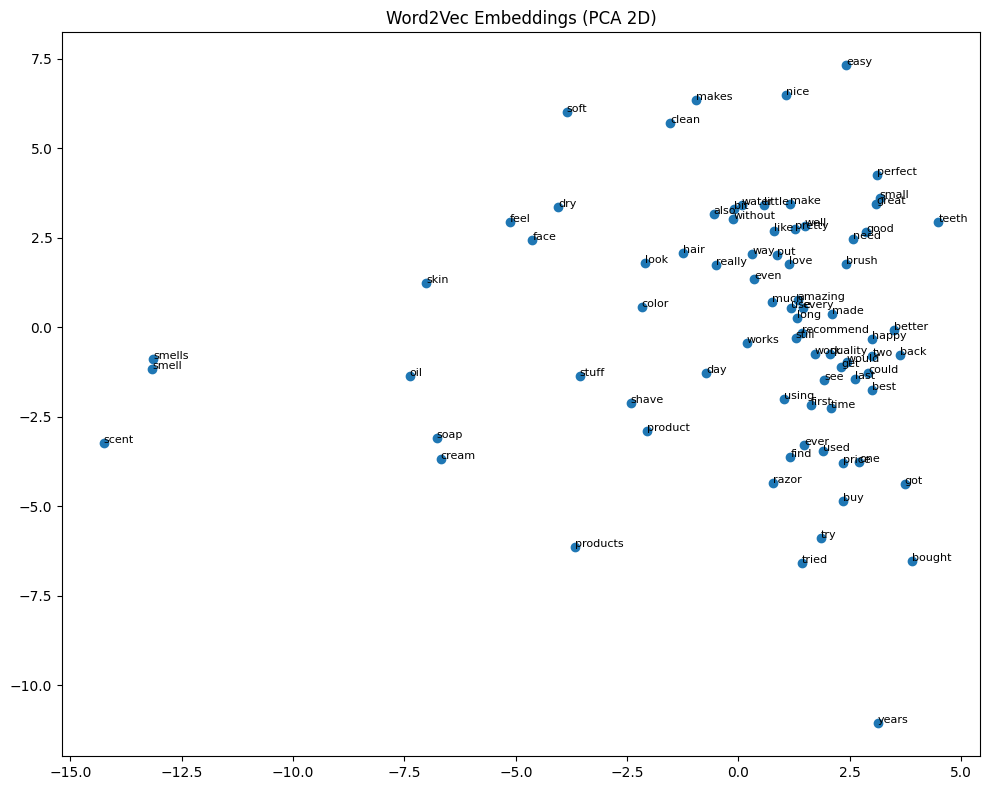

In [26]:

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

sentences = df["tokens"].dropna().tolist()

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=20,
    workers=4,
    sg=0,     # 0=CBOW, 1=Skip-gram
    seed=SEED
)

print(w2v)
print("Vocab size:", len(w2v.wv.index_to_key))

def show_similar(word, topn=10):
    if word not in w2v.wv:
        print(f"'{word}' not in vocab")
        return
    print(word, "→", w2v.wv.most_similar(word, topn=topn))

for w in ["skin","hair","smell","cream","shampoo","dry","oily"]:
    show_similar(w, 10)

words = w2v.wv.index_to_key[:80]
vecs = w2v.wv[words]
coords = PCA(n_components=2, random_state=SEED).fit_transform(vecs)

plt.figure(figsize=(10,8))
plt.scatter(coords[:,0], coords[:,1])
for i,w in enumerate(words):
    plt.annotate(w, (coords[i,0], coords[i,1]), fontsize=8)
plt.title("Word2Vec Embeddings (PCA 2D)")
plt.tight_layout()
plt.show()


## 16) Optional — Class 12 neural baseline (quick 2 epochs)

In [27]:

try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras import layers, Model
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import train_test_split

    df_nn = df[df["rating_bucket"].isin(["Positive","Negative"])].copy()
    texts = df_nn["text_clean"].astype(str).tolist()
    y = (df_nn["rating_bucket"]=="Positive").astype(int).values

    X_train, X_test, y_train, y_test = train_test_split(
        texts, y, test_size=0.2, random_state=SEED, stratify=y
    )

    MAX_WORDS = 20000
    MAX_LEN = 150

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train)
    xtr = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
    xte = pad_sequences(tok.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding="post", truncating="post")

    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    emb = layers.Embedding(MAX_WORDS, 64)(inp)
    x = layers.GlobalAveragePooling1D()(emb)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    model.fit(xtr, y_train, validation_split=0.1, epochs=2, batch_size=256, verbose=1)

    p = model.predict(xte, verbose=0).ravel()
    print("Neural baseline ROC-AUC:", round(float(roc_auc_score(y_test, p)), 4))
except Exception as e:
    print("Skipping neural section:", e)


Epoch 1/2
962/962 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - auc: 0.7187 - loss: 0.4071 - val_auc: 0.9398 - val_loss: 0.2226
Epoch 2/2
962/962 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - auc: 0.9437 - loss: 0.2141 - val_auc: 0.9496 - val_loss: 0.2069
Neural baseline ROC-AUC: 0.953


## 17) Results checklist (figure-driven)

**RQ1**
- `rq1_tfidf_term_diff.csv` + TF-IDF difference bar chart  
- `rq1_logodds_pos_terms.csv`, `rq1_logodds_neg_terms.csv` (top 20 + short examples)  
- VADER rating alignment plot

**RQ2**
- `rq2_lda_pos_topics.csv`, `rq2_lda_neg_topics.csv` (topics + representative snippets)  
- silhouette plot + `rq2_cluster_top_terms.csv` + PCA scatter

**RQ3**
- `rq3_helpful_binary_performance.csv` (AUC/F1/Acc) + verified stratified AUC printed  
- `rq3_nb_coefficients.csv` (optional count model interpretability)

**Cross-cutting**
- NER summaries (labels/entities)
- `phi_pairs.csv` + phi network plot
- Word2Vec PCA + similarity checks


## 18) Appendix — Save a reproducible processed sample + list output files

In [33]:

sample_path = os.path.join(OUTPUT_DIR, "processed_sample.parquet")
df.sample(min(50000, len(df)), random_state=SEED).to_parquet(sample_path, index=False)

print("Saved:", sample_path)
print("Output files:", os.listdir(OUTPUT_DIR))


Saved: /content/outputs_allbeauty/processed_sample.parquet
Output files: ['rq2_cluster_top_terms.csv', 'rq2_lda_pos_topics.csv', 'rq1_logodds_pos_terms.csv', 'rq1_tfidf_term_diff.csv', 'posneg_classification_performance.csv', 'rq3_nb_coefficients.csv', 'rq1_logodds_neg_terms.csv', 'rq3_helpful_binary_performance.csv', 'rq2_lda_neg_topics.csv', 'phi_pairs.csv', 'processed_sample.parquet']
